# 02 · Feature engineering

Construcción y validación de las features pre-partido (`src/features/`). Todo análisis de este notebook usa **solo
temporadas de entrenamiento (2002-03 a 2020-21)**: validación (2021-23) y test (2023-26) no se miran acá.

**Diseño anti-fuga.** Cada feature es el *estado del equipo al comienzo del día del partido*: se calcula el estado
después de cada partido ya jugado y, para un partido del día *D*, se toma el último estado con fecha **estrictamente
anterior** a *D* (`merge_asof` sin coincidencias exactas). El calendario de la temporada sí se considera conocido
(se publica antes de que empiece). El mismo código sirve para partidos históricos y para partidos futuros sin resultado.

In [1]:
import sys
sys.path.insert(0, '..')  # raíz del proyecto, para importar src

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from src import viz
from src.config import TRAIN_SEASONS, PROCESSED_DIR
from src.data.load import load_matches
from src.features.build import ELO_PARAMS_PATH, POST_MATCH_COLUMNS, build_features

viz.use_style()
pd.set_option("display.max_columns", 60, "display.width", 160, "display.float_format", "{:.3f}".format)
RNG = np.random.default_rng(42)

matches = load_matches()
features, elo_history = build_features(matches)
train = features[features.season_start.isin(TRAIN_SEASONS) & features.played].copy()
train["home_goals"] = train.home_goals.astype(float); train["away_goals"] = train.away_goals.astype(float)
print(f"Partidos de Premier con features: {len(features):,} | entrenamiento (2002-03 a 2020-21): {len(train):,}")

Partidos de Premier con features: 9,930 | entrenamiento (2002-03 a 2020-21): 7,220


## 1 · Diccionario de features

Todas incluyen Premier League **y Championship** (un recién ascendido llega con historia); la tabla es por división.
Limitación: solo partidos de liga (sin copas ni competiciones europeas), igual que en el EDA.

In [2]:
FEATURES = {
    "elo_home / elo_away / elo_diff": "Elo propio previo al partido (Premier + Championship)",
    "elo_expected_home": "Puntaje esperado del local según Elo, con ventaja de local",
    "ppg_last5_home / _away": "Puntos por partido en los últimos 5 partidos de liga",
    "gf_ewm / ga_ewm (_home / _away)": "Goles a favor / en contra, media exponencial (vida media 8 partidos)",
    "ppg / gdpg / position (_home / _away)": "Tabla de la temporada antes del día del partido",
    "games_played (_home / _away)": "Partidos de liga jugados en la temporada",
    "rest_days (_home / _away)": "Días desde el último partido de liga",
    "matches_last21 (_home / _away)": "Partidos de liga en los 21 días previos",
    "season_opener (_home / _away)": "Primer partido de liga del equipo en la temporada",
    "h2h_n / h2h_residual": "Cruces previos y residuo de Elo suavizado del cruce",
    "no_crowds": "Partido de la era sin público (17/06/2020 a 23/05/2021)",
}
pd.Series(FEATURES, name="descripción").to_frame()

,descripción
elo_home / elo_away / elo_diff,Elo propio previo al partido (Premier + Champi...
elo_expected_home,"Puntaje esperado del local según Elo, con vent..."
ppg_last5_home / _away,Puntos por partido en los últimos 5 partidos d...
gf_ewm / ga_ewm (_home / _away),"Goles a favor / en contra, media exponencial (..."
ppg / gdpg / position (_home / _away),Tabla de la temporada antes del día del partido
games_played (_home / _away),Partidos de liga jugados en la temporada
rest_days (_home / _away),Días desde el último partido de liga
matches_last21 (_home / _away),Partidos de liga en los 21 días previos
season_opener (_home / _away),Primer partido de liga del equipo en la temporada
h2h_n / h2h_residual,Cruces previos y residuo de Elo suavizado del ...


## 2 · Verificación de ausencia de fuga

Además de los tests unitarios (`tests/test_features.py`: invariancia al futuro sobre una liga sintética con ascensos
y descensos, y que alterar las estadísticas del propio partido no cambie ninguna feature), el chequeo se repite
sobre los datos reales: se borran resultados y estadísticas desde el día *D* y las features del día *D* deben ser idénticas.

In [3]:
# Chequeo de invariancia al futuro sobre los datos REALES: se borran todos los resultados y
# estadísticas desde el día D (el calendario se conserva) y las features del día D deben ser idénticas.
feature_cols = [c for c in features.columns if c not in POST_MATCH_COLUMNS and c != "played"]
for cutoff in ["2010-12-26", "2021-08-13"]:
    c = pd.Timestamp(cutoff)
    blanked = matches.copy()
    blanked.loc[blanked.date >= c, POST_MATCH_COLUMNS] = np.nan
    partial, _ = build_features(blanked)
    a = features.loc[features.date == c, feature_cols].reset_index(drop=True)
    b = partial.loc[partial.date == c, feature_cols].reset_index(drop=True)
    pd.testing.assert_frame_equal(a, b, check_dtype=False)
    print(f"{cutoff}: {len(a)} partidos con features idénticas sin conocer resultados desde ese día ✔")

2010-12-26: 7 partidos con features idénticas sin conocer resultados desde ese día ✔


2021-08-13: 1 partidos con features idénticas sin conocer resultados desde ese día ✔


## 3 · Elo propio

Fórmula (verificada en Hvattum y Arntzen 2010, *International Journal of Forecasting* 26(3)): expectativa logística con
base 10 y divisor 400, actualización `R' = R + k·(resultado − esperado)` y factor dependiente de la diferencia de goles
`k = k0·(1 + |dif|)^λ` (su variante ELOg; el paper usa k0 = 10, λ = 1). La ventaja de local se suma al rating del
local dentro de la expectativa, como en las World Football Elo Ratings.

**Ajuste** (`src/features/tune_elo.py`): descenso por coordenadas minimizando el log loss de un logit multinomial
`resultado ~ diferencia de Elo` en Premier League, **temporadas de entrenamiento**. La ventaja de local no se elige por
log loss (el criterio es plano: entre 0 y 100 puntos cambia ~0,0002) sino por **calibración**: el valor que hace que el
puntaje esperado del local entre equipos iguales coincida con el observado en entrenamiento (59,4 puntos).

In [4]:
tuning = json.loads(ELO_PARAMS_PATH.read_text(encoding="utf-8"))
print("Parámetros ajustados:", tuning["params"])
ref = tuning["reference_log_loss"]
pd.DataFrame({
    "log loss (entrenamiento)": [ref["paper_params"], ref["clubelo"], ref["tuned"]],
}, index=["Elo propio, parámetros del paper (k0=10, λ=1, h=100)", "ClubElo (snapshots)", "Elo propio ajustado"]).style.format("{:.5f}")

Parámetros ajustados: {'k0': 7.5, 'lam': 1.0, 'home_advantage': 59.4, 'season_regression': 0.05, 'initial_gap': 250, 'newcomer_offset': -50}


,log loss (entrenamiento)
"Elo propio, parámetros del paper (k0=10, λ=1, h=100)",0.97487
ClubElo (snapshots),0.97423
Elo propio ajustado,0.97359


In [5]:
pd.DataFrame(tuning["trace"]).drop_duplicates(subset=list(tuning["params"]), keep="first").style.format({"log_loss": "{:.5f}"}, precision=2)

,pass,k0,lam,home_advantage,season_regression,initial_gap,newcomer_offset,log_loss
0,0,10.00,1.00,59.40,0.00,100,0,0.97481
1,1,7.50,1.00,59.40,0.00,100,0,0.97449
3,1,7.50,1.00,59.40,0.05,100,0,0.97438
4,1,7.50,1.00,59.40,0.05,250,0,0.97368
5,1,7.50,1.00,59.40,0.05,250,-50,0.97359


* El Elo propio ajustado mejora a los parámetros del paper y **también al de ClubElo** en la misma muestra. La mejora es
  chica (milésimas de log loss), pero se consigue con un rating reproducible, actualizado partido a partido y sin
  depender de un servicio que dejó de publicar su API.
* Todos los parámetros elegidos quedaron **dentro** de sus grillas (una primera corrida dejó dos en el borde y se amplió).
* `season_regression = 0,05`: casi no hace falta regresar a la media entre temporadas; `newcomer_offset = −50`: los que
  suben desde League One arrancan algo por debajo de la media de la Championship.

In [6]:
both = features.dropna(subset=["clubelo_home"])
print("Correlación Elo propio vs ClubElo (rating del local):", round(both.elo_home.corr(both.clubelo_home), 3))
print("Correlación de la diferencia local-visitante:", round(both.elo_diff.corr(both.clubelo_diff), 3))
by_period = both.groupby(both.clubelo_provisional).apply(lambda g: g.elo_diff.corr(g.clubelo_diff))
print("Correlación de diferencias, ClubElo real vs provisional (desde 06/2025):", by_period.round(3).to_dict())

Correlación Elo propio vs ClubElo (rating del local): 0.961
Correlación de la diferencia local-visitante: 0.984
Correlación de diferencias, ClubElo real vs provisional (desde 06/2025): {False: 0.984, True: 0.981}


El Elo propio y ClubElo están muy correlacionados (0,98 en la diferencia local-visitante), también en el período
provisional de ClubElo: miden lo mismo, con otra frecuencia de actualización. El historial por equipo (abajo) es la base
del gráfico de "evolución del Elo" de la web.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


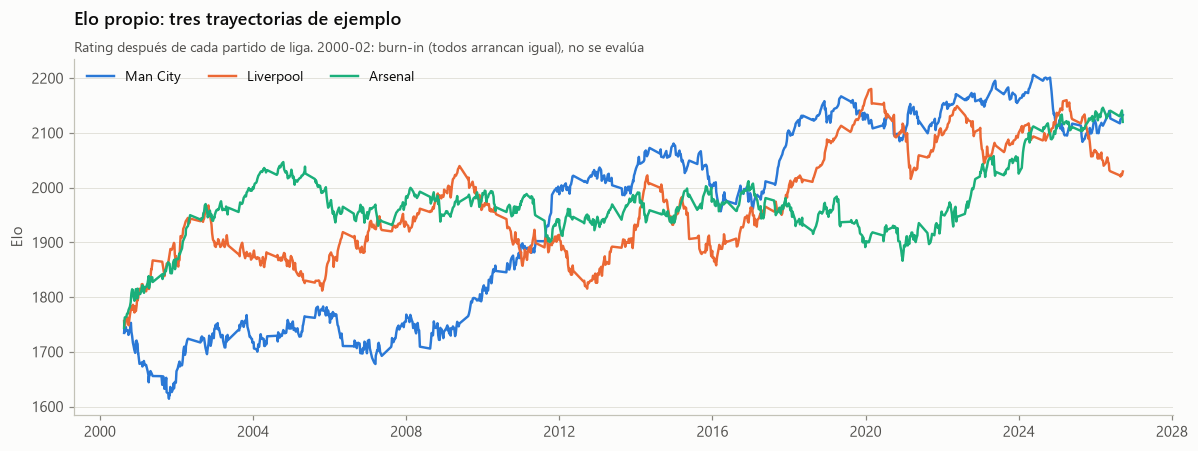

In [7]:
TEAMS = {"Man City": viz.BLUE, "Liverpool": viz.ORANGE, "Arsenal": viz.AQUA}
fig, ax = plt.subplots(figsize=(11, 4.2))
for team, color in TEAMS.items():
    h = elo_history[elo_history.team == team].sort_values("date")
    ax.plot(h.date, h.elo_after, color=color, linewidth=1.6, label=team)
ax.set_title("Elo propio: tres trayectorias de ejemplo")
viz.subtitle(ax, "Rating después de cada partido de liga. 2000-02: burn-in (todos arrancan igual), no se evalúa")
ax.set_ylabel("Elo"); ax.legend(loc="upper left", ncol=3)
fig.tight_layout(); fig.savefig("../reports/figures/fe_elo_trajectories.png"); plt.show()

## 4 · Señal univariada (entrenamiento)

Correlación de Spearman de cada feature con los goles del local y del visitante, con IC 95% por bootstrap.
Es descriptivo: sirve para detectar features sin señal o con el signo al revés, no para elegir el modelo.

In [8]:
# Señal univariada en ENTRENAMIENTO: correlación de Spearman de cada feature con los goles del local
# y del visitante, e IC 95% por bootstrap. Es descriptivo: la selección real se hace en validación.
candidates = ["elo_diff", "elo_expected_home", "clubelo_diff",
              "ppg_last5_home", "ppg_last5_away", "gf_ewm_home", "ga_ewm_home", "gf_ewm_away", "ga_ewm_away",
              "ppg_home", "ppg_away", "gdpg_home", "gdpg_away", "position_home", "position_away",
              "rest_days_home", "rest_days_away", "matches_last21_home", "matches_last21_away", "h2h_residual"]

def spearman_ci(x, y, n_boot=1000):
    ok = ~(np.isnan(x) | np.isnan(y)); x, y = x[ok], y[ok]
    rho = stats.spearmanr(x, y).statistic
    idx = RNG.integers(0, len(x), size=(n_boot, len(x)))
    boots = [stats.spearmanr(x[i], y[i]).statistic for i in idx]
    return rho, *np.percentile(boots, [2.5, 97.5]), len(x)

rows = []
for col in candidates:
    x = train[col].astype(float).to_numpy()
    for target in ("home_goals", "away_goals"):
        rho, lo, hi, n = spearman_ci(x, train[target].to_numpy())
        rows.append({"feature": col, "target": target, "rho": rho, "ci_low": lo, "ci_high": hi, "n": n})
signal = pd.DataFrame(rows).pivot(index="feature", columns="target", values=["rho", "ci_low", "ci_high"])
signal = signal.reindex(candidates)
signal.style.format("{:+.3f}").background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4, subset=[("rho", "home_goals"), ("rho", "away_goals")])

**Lectura:**
* La **diferencia de Elo** es la señal más fuerte (ρ = +0,33 con los goles del local, −0,30 con los del visitante).
* Tabla (puntos y diferencia de gol por partido, posición), forma reciente y goles ponderados tienen señal moderada
  (|ρ| entre 0,12 y 0,21) y **todos con el signo esperado**. Parte de esa información ya está en el Elo (ver redundancia).
* **Descanso y congestión: prácticamente sin señal** (|ρ| ≤ 0,02). Es coherente con la limitación documentada: el
  índice solo ve partidos de liga, no la fatiga real por copas y Europa.
* **Head-to-head: señal mínima y con signo contrario** (ver sección 6).

## 5 · Redundancia entre features

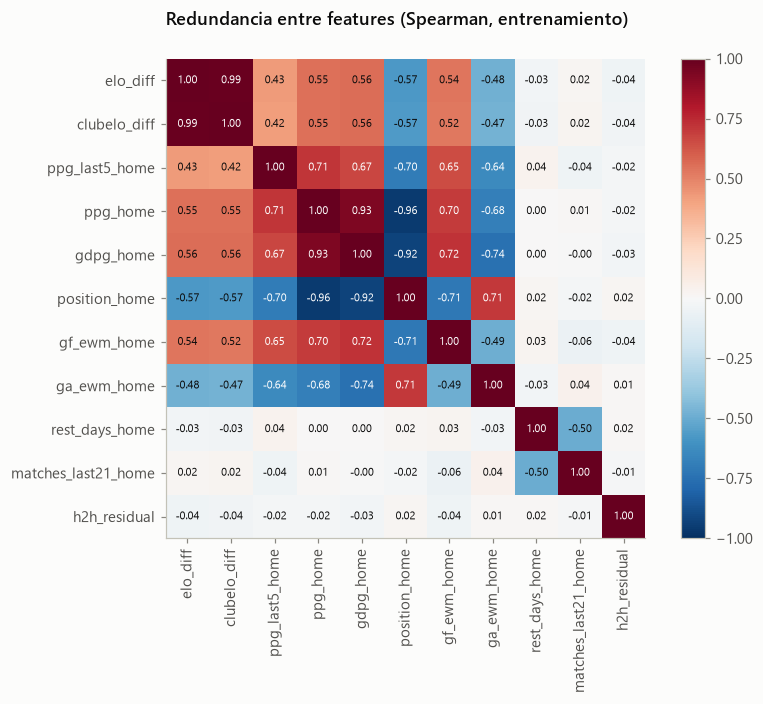

In [9]:
corr_cols = ["elo_diff", "clubelo_diff", "ppg_last5_home", "ppg_home", "gdpg_home", "position_home",
             "gf_ewm_home", "ga_ewm_home", "rest_days_home", "matches_last21_home", "h2h_residual"]
corr = train[corr_cols].astype(float).corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=90); ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i, j]) > 0.6 else viz.INK)
ax.grid(False); ax.set_title("Redundancia entre features (Spearman, entrenamiento)")
fig.colorbar(im, ax=ax, fraction=0.04); fig.tight_layout(); plt.show()

Elo, ClubElo, puntos por partido, diferencia de gol por partido y posición están fuertemente correlacionados: miden
"qué tan bueno es el equipo". Para un modelo lineal (la regresión de Poisson) esto implica colinealidad: coeficientes
inestables aunque las predicciones sean buenas. Se tratará con regularización y con selección por validación.

## 6 · ¿El head-to-head aporta algo que el Elo no sepa?

La hipótesis a testear es que, en un cruce específico, un equipo rinde sistemáticamente por encima de lo que su
fuerza predice. Si fuera así, el residuo de Elo acumulado en cruces previos debería correlacionar **positivamente** con
el residuo del partido actual.

In [10]:
# ¿El h2h agrega algo que el Elo no sabe? Se correlaciona el residuo h2h previo con el residuo
# del partido actual (puntaje real - esperado por Elo). Si el h2h no aporta, debería dar ~0.
alpha = np.select([train.home_goals > train.away_goals, train.home_goals == train.away_goals], [1.0, 0.5], 0.0)
current_resid = alpha - train.elo_expected_home.to_numpy()
for min_n in (0, 3, 10):
    sel = (train.h2h_n >= min_n).to_numpy()
    r, lo, hi, n = spearman_ci(train.h2h_residual.to_numpy()[sel], current_resid[sel])
    print(f"cruces previos >= {min_n:2d}: rho = {r:+.3f}  IC95% [{lo:+.3f}, {hi:+.3f}]  (n = {n:,})")

cruces previos >=  0: rho = -0.031  IC95% [-0.052, -0.008]  (n = 7,220)


cruces previos >=  3: rho = -0.029  IC95% [-0.054, -0.006]  (n = 6,372)


cruces previos >= 10: rho = -0.046  IC95% [-0.078, -0.011]  (n = 3,648)


**Resultado: no hay evidencia de un "efecto cruce".** La correlación es muy chica y **negativa** (ρ ≈ −0,03, el IC excluye
el 0). Una explicación plausible es la reversión a la media: si un equipo sobre-rindió en cruces previos, esos resultados
ya subieron su Elo, así que en el siguiente cruce la expectativa queda algo inflada. El hallazgo contradice la intuición
futbolera de "equipo que es bestia negra de otro". Se mantiene como candidata y se decide en validación, pero lo esperable
es que **no entre** en el modelo final (se documentará igual en la web).

## 7 · Descanso y congestión, controlando por fuerza

Residuo de Elo del local (resultado real − esperado) según la diferencia de días de descanso y de partidos en 21 días.

In [11]:
# Descanso: goles y resultado del local según diferencia de descanso (local - visitante), sin aperturas de temporada.
sub = train[~train.season_opener_home & ~train.season_opener_away].copy()
sub["rest_diff"] = (sub.rest_days_home - sub.rest_days_away).clip(-7, 7)
sub["resid"] = np.select([sub.home_goals > sub.away_goals, sub.home_goals == sub.away_goals], [1.0, 0.5], 0.0) - sub.elo_expected_home
table = sub.groupby(pd.cut(sub.rest_diff, [-8, -3, -1, 0, 2, 7])).agg(
    partidos=("resid", "size"), residuo_elo_medio=("resid", "mean"), goles_local=("home_goals", "mean"), goles_visitante=("away_goals", "mean"))
table["IC95% residuo"] = [f"±{1.96 * g.resid.std() / np.sqrt(len(g)):.3f}" for _, g in sub.groupby(pd.cut(sub.rest_diff, [-8, -3, -1, 0, 2, 7]))]
table

,partidos,residuo_elo_medio,goles_local,goles_visitante,IC95% residuo
rest_diff,,,,,
"(-8, -3]",315,-0.004,1.422,1.057,±0.043
"(-3, -1]",1522,0.013,1.684,1.072,±0.019
"(-1, 0]",3355,0.021,1.515,1.140,±0.013
"(0, 2]",1550,0.021,1.430,1.268,±0.020
"(2, 7]",285,0.020,1.404,1.126,±0.045


In [12]:
sub["cong_diff"] = sub.matches_last21_home - sub.matches_last21_away
sub.groupby("cong_diff").agg(partidos=("resid", "size"), residuo_elo_medio=("resid", "mean")).query("partidos >= 100")

,partidos,residuo_elo_medio
cong_diff,,
-1,784,0.014
0,5295,0.019
1,814,0.009


El residuo medio es de ~+0,02 en todas las categorías (un pequeño sesgo general de la expectativa de Elo, que el modelo
absorbe con su intercepto). Lo relevante es que **no varía de forma sistemática** con el descanso ni con la congestión:
las diferencias entre grupos están dentro de los intervalos. Con los datos disponibles (solo liga) estas features no
muestran efecto. Se evaluarán en validación, pero no se espera que aporten.

## 8 · Valores faltantes

In [13]:
feat_cols = [c for c in features.columns if c.endswith(("_home", "_away")) and not c.startswith(("b365", "psc", "clubelo"))
             and c not in POST_MATCH_COLUMNS] + ["h2h_residual", "no_crowds"]
miss = features[feat_cols].isna().sum()
miss[miss > 0].to_frame("nulos").assign(motivo=lambda d: [
    "primer partido del equipo en los datos" if "last5" in c or "ewm" in c or "rest" in c
    else "primera fecha de la temporada (sin tabla)" for c in d.index])

,nulos,motivo
ppg_last5_home,10,primer partido del equipo en los datos
gf_ewm_home,10,primer partido del equipo en los datos
ga_ewm_home,10,primer partido del equipo en los datos
rest_days_home,10,primer partido del equipo en los datos
ppg_home,270,primera fecha de la temporada (sin tabla)
gdpg_home,270,primera fecha de la temporada (sin tabla)
position_home,270,primera fecha de la temporada (sin tabla)
ppg_last5_away,10,primer partido del equipo en los datos
gf_ewm_away,10,primer partido del equipo en los datos
ga_ewm_away,10,primer partido del equipo en los datos


Los faltantes son **estructurales** y pocos: 10 equipo-partidos sin historia (la primera fecha de 2000-01, dentro del
burn-in que no se evalúa) y 270 primeras fechas de temporada sin tabla. Tratamiento para el modelo: en la primera fecha,
las features de tabla se reemplazan por un valor neutro y el indicador `season_opener` le permite al modelo distinguirlo.

## 9 · Conclusiones para la etapa de modelado

1. **Sin fuga**, verificado por construcción, con tests sobre datos sintéticos y con el chequeo sobre datos reales.
2. **Elo propio** ajustado solo con entrenamiento: mejor que los parámetros del paper y que ClubElo en la misma muestra.
3. Señal clara: Elo, tabla, forma y goles ponderados (muy redundantes entre sí).
4. Sin señal visible: descanso, congestión (limitación de datos: solo liga) y head-to-head (signo contrario, efecto mínimo).
   Se evalúan en validación y, si no mejoran el log loss, quedan fuera del modelo final: se reporta igual como resultado.